Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

Load Dataset

In [5]:
df = pd.read_csv("C:\\Users\\PCSS\\OneDrive\\Desktop\\14 may\\Healthcare Predictive Analytics\\heart.csv")

print(df.head())
print(df.info())
print(df.describe())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

Data Cleaning

In [7]:
# Check Missing Values
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [8]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

Encode Categorical Variables

In [9]:
df=pd.get_dummies(df,drop_first=True)

Normalize Medical Data

In [10]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Train Classification Models

In [ ]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8532608695652174


In [13]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.875


In [14]:
# Evaluate Model
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [15]:
# Feature Importance Analysis
importance = rf.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

print(feature_importance.sort_values(
    by='Importance',
    ascending=False
))

              Feature  Importance
14        ST_Slope_Up    0.149099
4               MaxHR    0.117511
5             Oldpeak    0.112069
13      ST_Slope_Flat    0.108416
2         Cholesterol    0.103851
12   ExerciseAngina_Y    0.101613
0                 Age    0.088802
1           RestingBP    0.071584
6               Sex_M    0.036660
7   ChestPainType_ATA    0.033246
8   ChestPainType_NAP    0.023194
3           FastingBS    0.022405
10  RestingECG_Normal    0.015478
11      RestingECG_ST    0.009124
9    ChestPainType_TA    0.006949


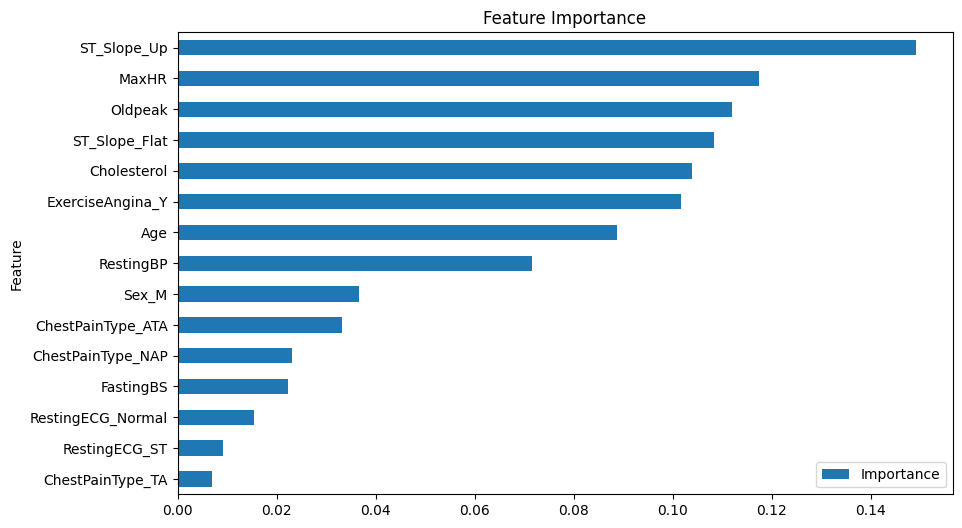

In [16]:
# Visualization
feature_importance.sort_values(
    by='Importance',
    ascending=True
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.show()